# AICE Associate 예상 문제 1회: 중고차 가격 예측

**과제: 중고차 가격 예측 AI 모델 개발**

**도메인: 자동차**

**배경:**
최근 중고차 시장은 온라인 플랫폼의 활성화와 함께 급격하게 성장하고 있습니다. 수많은 매물이 쏟아지는 상황에서, 소비자들은 합리적인 가격에 차량을 구매하기를 원하고 판매자들은 본인 차량의 적정 시세를 알고 싶어 합니다. 이에 중고차 거래 플랫폼 'AICE 모터스'는 AI 모델을 통해 판매자와 구매자 모두에게 신뢰도 높은 가격 정보를 제공하고자 합니다.

**데이터셋 설명 (파일명: `1_used_car_prices.csv`)**

* `brand`: 차량 제조사
* `age_years`: 차량의 연식
* `mileage_km`: 총 주행거리
* `engine_type`: 엔진 종류
* `engine_size_cc`: 배기량
* `horsepower`: 차량의 출력
* `fuel_efficiency_kml`: 연비
* `accident_count`: 사고 이력 횟수
* `color`: 차량의 색상
* `option_grade`: 옵션 등급
* **`price_krw`**: **예측 목표(Target)**, 중고차 거래 가격 (단위: 만원)

--- 
#### **사전 실행 코드**
> 모든 문제를 풀기 전에 아래 코드를 실행해주세요.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

--- 
#### **문제 1.**

`seaborn`은 Matplotlib을 기반으로 더 다채롭고 통계적인 그래프를 쉽게 그릴 수 있도록 도와주는 시각화 라이브러리입니다. `seaborn` 라이브러리를 별칭 `sns`로 임포트하는 코드를 작성하세요.

In [3]:
# 여기에 답안코드를 작성하세요.
import seaborn as sns

#### **[해설 및 핵심 이론] 문제 1**

* **상세 해설**  
    `import 라이브러리 as 별칭` 구문을 사용하여 `seaborn` 라이브러리를 `sns`라는 표준 별칭으로 불러옵니다.

In [ ]:
# 답안
import seaborn as sns

--- 
#### **문제 2.**

AI 모델링을 위해 분석할 데이터를 준비하려고 합니다. 아래 가이드에 따라 코드를 작성하세요.

1.  Pandas의 `read_csv` 함수를 사용하여 `1_used_car_prices.csv` 파일을 읽어 데이터프레임 변수 `car_df`에 할당하세요.
2.  불러온 `car_df`의 `info()`를 통해 확인하고, 결측치가 32개가 존재하는 변수가 무엇인지 `답안01`에 작성하세요.

In [4]:
# 여기에 답안코드를 작성하세요.
import pandas as pd

car_df = pd.read_csv('../data/1_used_car_prices.csv')
car_df.info()
car_df.isnull().sum()

# 답안 예
답안01 = 'color'

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                961 non-null    str    
 1   age_years            974 non-null    float64
 2   mileage_km           970 non-null    float64
 3   engine_type          979 non-null    str    
 4   engine_size_cc       970 non-null    float64
 5   horsepower           979 non-null    float64
 6   fuel_efficiency_kml  974 non-null    float64
 7   accident_count       972 non-null    float64
 8   color                968 non-null    str    
 9   option_grade         973 non-null    str    
 10  price_krw            1000 non-null   float64
dtypes: float64(7), str(4)
memory usage: 86.1 KB


#### **[해설 및 핵심 이론] 문제 2**

* **상세 해설**  
    `pandas`의 `read_csv()` 함수를 사용하여 지정된 파일명의 데이터를 읽어 `car_df` 데이터프레임에 저장합니다.  
    그 후, `info()` 메소드를 사용하여 데이터프레임의 전체적인 구조, 각 컬럼의 데이터 타입, 결측치 현황 등을 파악합니다.

In [5]:
# 답안

# '1_used_car_prices.csv' 파일을 읽어 car_df 변수에 저장합니다.
car_df = pd.read_csv('C:\\Users\\User\\Desktop\\2026 이패스 AI능력시험 AI Associate 실전모의고사 10_DATA\\2026 이패스 AI능력시험 AI Associate 실전모의고사 10_DATA\\1_used_car_prices.csv')

# 데이터프레임의 요약 정보 확인
car_df.info()
답안02 = 'color'

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\2026 이패스 AI능력시험 AI Associate 실전모의고사 10_DATA\\2026 이패스 AI능력시험 AI Associate 실전모의고사 10_DATA\\1_used_car_prices.csv'

--- 
#### **문제 3.**

`engine_type`별로 차량 가격에 차이가 있는지 확인하려고 합니다.  
`seaborn`의 `barplot`을 사용하여 `engine_type`에 따른 `price_krw`의 평균을 시각화하고, 가장 평균 가격이 높은 엔진 타입을 `답안03` 변수에 문자열로 저장하세요.

* **x축**: `engine_type`
* **y축**: `price_krw`
* **데이터**: `car_df`

In [6]:
# 한글화를 위해 아래의 코드를 작성해 주세요.
import platform
from matplotlib import rc

if platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')
else:  # Windows
    rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

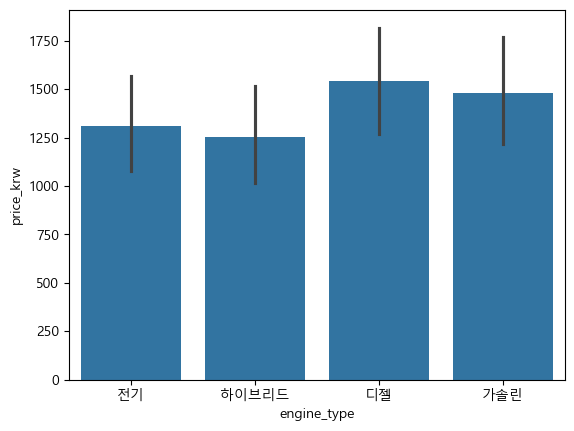

In [7]:
# 답안
import seaborn as sns
sns.barplot(car_df, x='engine_type', y='price_krw')

답안03 = '디젤'

#### **[해설 및 핵심 이론] 문제 3**

* **상세 해설**  
    `seaborn`의 `barplot`은 x축에 지정된 범주형 변수의 각 그룹에 대한 y축 변수의 평균값을 막대그래프로 보여줍니다.  
   `x='engine_type'`, `y='price_krw'`으로 설정하여 그래프를 그리면, '디젤' 엔진 타입의 평균 가격이 가장 높은 것을 시각적으로 확인할 수 있습니다.

* **핵심 이론**  
    * **`sns.barplot(data, x, y)`**: x축에 지정된 범주형 데이터의 각 그룹에 대해 y축에 지정된 수치형 데이터의 '평균'을 계산하여 막대그래프로 보여줍니다.  
    * 그룹 간 평균을 비교할 때 유용합니다. 신뢰구간(막대 위 검은 선)도 함께 표시하여 평균값의 불확실성을 나타냅니다.

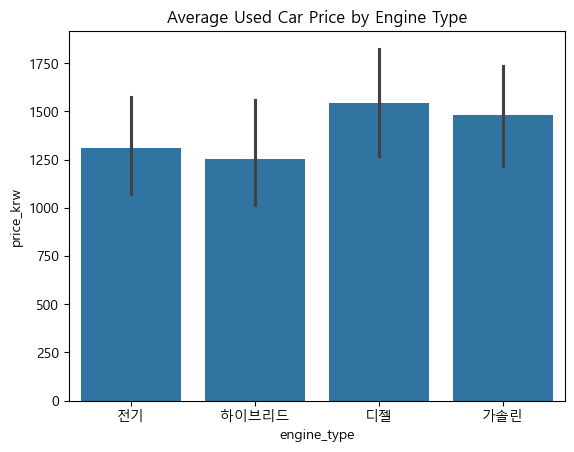

In [8]:
# 답안

# seaborn의 barplot을 사용하여 엔진타입별 평균 가격을 시각화합니다.
sns.barplot(data=car_df, x='engine_type', y='price_krw')
plt.title('Average Used Car Price by Engine Type')

# 그래프를 통해 '디젤'의 평균 가격이 가장 높음을 알 수 있습니다.
답안03 = '디젤'

--- 
#### **문제 4.**

`brand`와 `option_grade`를 조합했을 때의 평균 가격을 확인하고자 합니다. `groupby()`를 사용하여 데이터를 `brand`와 `option_grade`로 그룹화하고, `price_krw`의 평균을 계산하세요. 계산된 결과에서 가장 평균 가격이 높은 조합의 `brand`와 `option_grade`를 `답안04` 변수에 문자열로 저장하세요.

In [9]:
# 여기에 답안코드를 작성하세요.
grouped_price = car_df.groupby(['brand', 'option_grade'])['price_krw'].mean()
highest = grouped_price.idxmax()

print(highest)

# 가장 평균 가격이 높은 브랜드명을 아래 변수에 저장하세요.
답안04 = 'C사, 기본'

('C사', '기본')


#### **[해설 및 핵심 이론] 문제 4**

* **상세 해설**  
    `groupby()`에 리스트 형태로 여러 컬럼(`['brand', 'option_grade']`)을 전달하여 다중 그룹화를 수행합니다.  
그 후 `['price_krw']` 컬럼을 선택하고 `.mean()`으로 평균을 계산합니다. `.idxmax()` 함수는 가장 큰 값을 가진 인덱스(여기서는 멀티 인덱스)를 반환합니다. `('C사', '기본')`이 가장 높은 평균 가격을 가지므로, brand와 option_grade는 'C사, 기본'입니다.

* **핵심 이론**
    * **`df.groupby(by=[...])`**: 지정된 컬럼(들)을 기준으로 데이터를 그룹으로 묶어주는 매우 강력한 기능입니다.  
    뒤에 `.mean()`, `.sum()`, `.count()` 등 집계 함수를 붙여 의미 있는 결과를 얻습니다.
    * **`.idxmax()`**: Series에서 가장 큰 값을 가진 인덱스를 반환합니다. `groupby` 결과에 사용하면 특정 조건에서 최댓값을 갖는 그룹을 쉽게 찾을 수 있습니다.

In [7]:
# 답안

# 'brand'와 'option_grade'으로 그룹화하여 가격의 평균을 계산합니다.
grouped_price = car_df.groupby(['brand', 'option_grade'])['price_krw'].mean()
print(grouped_price)

# 가장 평균 가격이 높은 그룹의 인덱스를 찾습니다. 이 부분은 groupby에 대한 결과를 보고 풀어도 무방하며, 아래 코드는 참고하시면 됩니다.
highest_price_combo = grouped_price.idxmax()
print(f"\n가장 평균 가격이 높은 조합: {highest_price_combo}")

# 해당 조합의 브랜드명을 답안으로 저장합니다.
답안04 = 'C사, 기본'

NameError: name 'car_df' is not defined

--- 
#### **문제 5.**

모델링 성능을 높이기 위해 데이터를 정제하려고 합니다.  
`option_grade` 컬럼의 결측치(NaN)를 해당 컬럼에서 가장 자주 나타나는 값(최빈값)으로 채우고, 분석에 사용하지 않을 `color` 컬럼을 삭제하는 코드를 작성하세요.  
전처리된 데이터프레임은 `car_pre` 변수에 저장하세요.

* **힌트**: 최빈값은 `.mode()[0]`으로 얻을 수 있습니다.

In [10]:
# 여기에 답안코드를 작성하세요.
cp_car_df = car_df.copy()

p = car_df['option_grade'].mode()[0]
cp_car_df['option_grade'].fillna(p, inplace=True)
cp_car_df.drop('color', axis=1, inplace=True)

car_pre = cp_car_df
display(car_pre.head(5))

C:\Users\jungs\AppData\Local\Temp\ipykernel_9160\2223256559.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  cp_car_df['option_grade'].fillna(p, inplace=True)


,brand,age_years,mileage_km,engine_type,engine_size_cc,horsepower,fuel_efficiency_kml,accident_count,option_grade,price_krw
0,B사,14.0,218413.0,전기,3253.0,333.0,8.6,3.0,고급,100.0
1,D사,11.0,90552.0,하이브리드,3294.0,327.0,8.3,0.0,고급,100.0
2,C사,13.0,178150.0,디젤,3805.0,387.0,4.8,0.0,중급,100.0
3,NaN,7.0,127044.0,하이브리드,1146.0,110.0,19.2,2.0,고급,100.0
4,A사,2.0,40116.0,디젤,3165.0,340.0,8.9,0.0,고급,3987.0


#### **[해설 및 핵심 이론] 문제 5**

* **상세 해설**

    먼저 원본 데이터프레임을 `copy()`하여 `car_pre`를 만듭니다. `option_grade`의 최빈값은 `car_pre['option_grade'].mode()[0]`으로 구합니다. 이 값을 `fillna()`를 사용하여 결측치에 채워 넣습니다. `.drop()` 함수를 사용하여 `color` 컬럼을 삭제합니다. `axis=1`은 컬럼을 삭제하겠다는 의미입니다.

* **핵심 이론**
    * **`df['컬럼명'].mode()[0]`**: 해당 컬럼에서 가장 자주 나타나는 값, 즉 최빈값을 반환합니다. 범주형 데이터의 결측치를 채울 때 주로 사용합니다.
    * **`df['컬럼명'].fillna(value, inplace=True)`**: 선택한 컬럼의 결측치(NaN)를 지정된 `value`로 채웁니다. `inplace=True`는 원본 데이터프레임에 변경사항을 바로 적용하라는 의미입니다.
    * **`df.drop('컬럼명', axis=1)`**: 지정된 컬럼 또는 행을 삭제합니다. `axis=1`은 '컬럼'을, `axis=0`은 '행'을 의미합니다.

In [ ]:
# 답안

# 원본 보존을 위해 데이터프레임을 복사합니다.
car_pre = car_df.copy()

# 1. option_grade 컬럼의 최빈값을 구합니다.
mode_option = car_pre['option_grade'].mode()[0]
print(f"option_grade의 최빈값: {mode_option}")

# 2. fillna를 사용하여 결측치를 최빈값으로 채웁니다.
car_pre['option_grade'].fillna(mode_option, inplace=True)

# 3. drop을 사용하여 'color' 컬럼을 삭제합니다.
car_pre.drop('color', axis=1, inplace=True)

--- 
#### **문제 6.**

머신러닝 모델은 문자열 데이터를 이해할 수 없으므로, 범주형 데이터를 숫자형으로 변환해야 합니다.  
`pandas`의 `get_dummies()` 함수를 사용하여 아래의 범주형 컬럼들을 원-핫 인코딩(One-Hot Encoding)으로 변환하세요.

* **대상 컬럼**: `brand`, `engine_type`, `option_grade`
* `brand` 컬럼의 결측치는 `get_dummies` 처리 전에 `'unknown'` 이라는 문자열로 채워주세요.
* 변환이 적용된 데이터프레임은 `car_numeric` 변수에 저장하세요.

In [13]:
# 여기에 답안코드를 작성하세요.
car_pre['brand'].fillna('unknown')
car_numeric = pd.get_dummies(car_pre, ['brand', 'engine_type', 'option_grade'])

display(car_numeric)

,age_years,mileage_km,engine_size_cc,horsepower,fuel_efficiency_kml,accident_count,price_krw,brand_A사,brand_B사,brand_C사,brand_D사,engine_type_가솔린,engine_type_디젤,engine_type_전기,engine_type_하이브리드,option_grade_고급,option_grade_기본,option_grade_중급
0,14.0,218413.0,3253.0,333.0,8.6,3.0,100.0,False,True,False,False,False,False,True,False,True,False,False
1,11.0,90552.0,3294.0,327.0,8.3,0.0,100.0,False,False,False,True,False,False,False,True,True,False,False
2,13.0,178150.0,3805.0,387.0,4.8,0.0,100.0,False,False,True,False,False,True,False,False,False,False,True
3,7.0,127044.0,1146.0,110.0,19.2,2.0,100.0,False,False,False,False,False,False,False,True,True,False,False
4,2.0,40116.0,3165.0,340.0,8.9,0.0,3987.0,True,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10.0,202059.0,3397.0,334.0,NaN,0.0,100.0,True,False,False,False,False,False,True,False,False,True,False
996,12.0,186219.0,2975.0,296.0,9.8,0.0,100.0,False,False,False,True,False,False,False,True,False,False,True
997,14.0,270304.0,2657.0,282.0,12.5,1.0,100.0,True,False,False,False,False,True,False,False,True,False,False
998,11.0,106943.0,3541.0,360.0,7.4,4.0,100.0,False,False,False,True,False,False,False,False,False,True,False


#### **[해설 및 핵심 이론] 문제 6**

* **상세 해설**  
    `get_dummies()`는 범주형 데이터를 여러 개의 0과 1로 이루어진 컬럼으로 변환해주는 강력한 함수입니다. 먼저 `brand` 컬럼의 결측치를 `'unknown'`으로 채웁니다. 그 후 `car_pre` 데이터프레임과 변환할 컬럼 리스트를 `get_dummies()` 함수에 전달하여 원-핫 인코딩을 수행합니다.

* **핵심 이론**  
    **`pd.get_dummies(data, columns=[...])`**: 범주형 데이터를 원-핫 인코딩으로 변환합니다. 모델이 문자를 이해할 수 없으므로, 각 카테고리를 별도의 컬럼으로 만들고 해당 여부를 0과 1로 표시해주는 필수적인 전처리 과정입니다.

In [ ]:
# 답안

# 6번 문제에서 처리된 car_pre 데이터프레임을 사용합니다.
# brand 컬럼의 결측치를 'unknown'으로 채웁니다.
car_pre['brand'].fillna('unknown', inplace=True)

# 변환할 범주형 컬럼 리스트
categorical_cols = ['brand', 'engine_type', 'option_grade']

# get_dummies를 사용하여 원-핫 인코딩을 수행합니다.
car_numeric = pd.get_dummies(car_pre, columns=categorical_cols)

# 변환 결과 확인
car_numeric.head()

--- 
#### **문제 7.**

데이터의 수치형 특성(Feature)들 간의 선형적 관계를 확인하고자 합니다.  
아래 가이드에 따라 `seaborn`의 `heatmap`을 생성하고, 출력 결과에 대한 올바른 해석을 선택하여 `답안07` 변수에 저장하세요.

* **대상 컬럼**: `age_years`, `mileage_km`, `engine_size_cc`, `horsepower`, `fuel_efficiency_kml`, `price_krw`
* **Heatmap 옵션**: 상관계수 값을 각 셀에 표시 (`annot=True`), 색상 맵은 `viridis` 사용
* 아래 코드를 실행하여 그래프를 확인하고 답안을 작성하세요.

<Axes: >

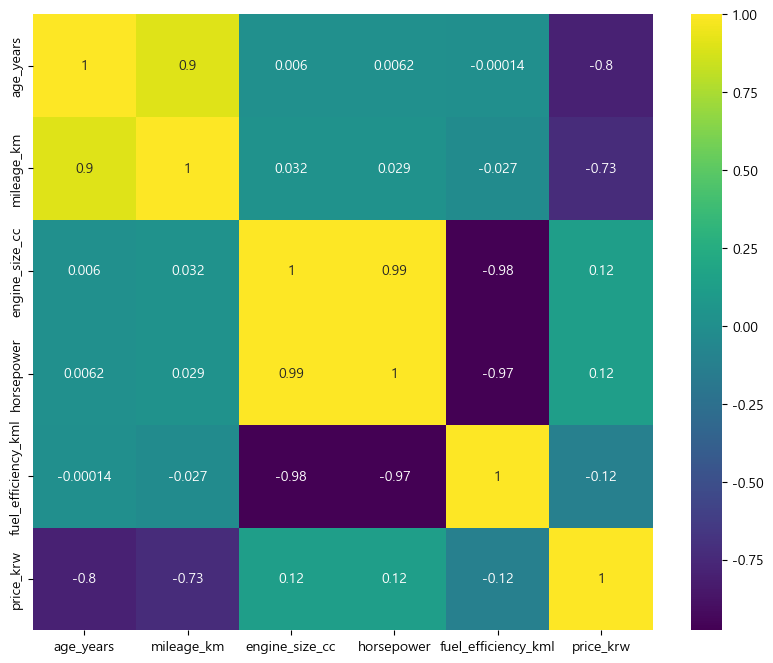

In [14]:
# 아래 코드를 실행하세요.
corr_cols = ['age_years', 'mileage_km', 'engine_size_cc', 'horsepower', 'fuel_efficiency_kml', 'price_krw']
plt.figure(figsize=(10, 8))
sns.heatmap(car_df[corr_cols].corr(), annot=True, cmap='viridis')

* **해석 선택지**
    1.  `price_krw`과 가장 강한 음의 상관관계를 갖는 특성은 `horsepower`이다.
    2.  `age_years`와 `mileage_km`는 서로 강한 음의 상관관계를 보인다.
    3.  `fuel_efficiency_kml`는 `price_krw`는 상관관계가 거의 없다고 봐도 무방하다.
    4.  `engine_size_cc`와 `horsepower`은 다중공선성을 의심하지 않아도 된다.

In [15]:
# 여기에 답안코드를 작성하세요.
답안07 = 3

#### **[해설 및 핵심 이론] 문제 7**

**상세 해설**  
상관계수 히트맵에서 `price_krw`와 가장 강한 음의 상관관계를 보이는 변수는 `age_years`(-0.77)입니다.  
`age_years`와 `mileage_km`은 0.86으로 높은 양의 상관을 보이며, `fuel_efficiency_km`와 `price_krw`는 -0.12로 상관이 거의 없습니다.   
`engine_size_cc`와 `horsepower`는 0.92로 매우 강한 양의 상관을 보여 다중공선성을 의심할 수 있습니다.

**핵심 이론**  
- **상관계수**: -1~1 사이 값으로 두 변수 간 선형 관계 강도를 나타냅니다. 절댓값이 클수록 관계가 강하며, 부호는 관계 방향(양/음)을 의미합니다.  
- **다중공선성**: 독립변수 간 상관이 높아(|r| ≥ 0.8) 회귀분석 결과의 신뢰도를 떨어뜨리는 현상입니다.

In [ ]:
# 답안
답안07 = 3

--- 
#### **문제 8.**

훈련과 검증에 사용할 데이터셋을 분리하려고 합니다. `price_krw` 컬럼을 label `y`로, 나머지 컬럼들을 feature `X`로 할당한 후 훈련 데이터셋과 검증 데이터셋으로 분리하는 코드를 작성하세요.

* **대상 데이터셋**: `car_numeric`
* `sklearn.model_selection`의 `train_test_split` 함수 사용
* **훈련:검증 데이터 비율**: 70:30
* **`random_state`**: 100 (결과 재현을 위해 고정)
* (주의) 회귀 문제이므로 `stratify` 옵션은 사용하지 않습니다.

In [ ]:
# 여기에 답안코드를 작성하세요.
from sklearn.model_selection import train_test_split

y = car_numeric['price_krw']
X = car_numeric.drop('price_krw', axis=1)

X_train, X_val, y_train, y_val = train_test_split(test_size=0.3, random_state=100)

#### **[해설 및 핵심 이론] 문제 8**

* **상세 해설**  
    먼저 `drop()`을 사용하여 `price_krw` 컬럼을 제외한 나머지를 `X`로, `price_krw` 컬럼을 `y`로 분리합니다. 그 후 `train_test_split` 함수에 `X`와 `y`를 넣고, `test_size=0.3` (검증 데이터 30%), `random_state=100`을 설정하여 데이터를 분리합니다.

* **핵심 이론**  
    * **`train_test_split(X, y, test_size, random_state)`**: 전체 데이터셋을 훈련용과 검증용으로 나누어주는 함수입니다.  
        * `test_size`: 검증용 데이터셋의 비율 (0.3은 30%를 의미).
        * `random_state`: 난수 생성의 시드(seed) 값. 이 값을 고정하면 매번 실행할 때마다 동일한 방식으로 데이터가 나뉘어 결과의 재현성을 보장합니다.  
        * **회귀 문제와 `stratify`**: 분류 문제에서는 `stratify=y` 옵션을 주어 타겟의 비율을 유지하지만, 연속된 값을 갖는 회귀 문제의 타겟(y)에는 비율 개념이 없으므로 이 옵션을 사용하지 않습니다.

In [18]:
# 답안

from sklearn.model_selection import train_test_split

# Feature(X)와 Label(y)을 분리합니다.
X = car_numeric.drop('price_krw', axis=1)
y = car_numeric['price_krw']

# 훈련 데이터와 검증 데이터로 분리합니다.
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=100)

# 분리 결과 확인
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (700, 17)
X_valid shape: (300, 17)


--- 
#### **문제 9.**

수치형 데이터들의 단위를 맞춰주기 위해 데이터 스케일링을 진행합니다. 모든 값을 0과 1 사이로 변환하는 `MinMaxScaler`를 사용하여 훈련 데이터와 검증 데이터의 Feature(`X_train`, `X_valid`)를 스케일링하는 코드를 작성하세요.

* `sklearn.preprocessing`의 `MinMaxScaler` 함수 사용
* 훈련 데이터에는 `fit_transform()`을, 검증 데이터에는 `transform()`을 적용하세요.
* 스케일링된 결과는 각각 `X_train_scaled`, `X_valid_scaled` 변수에 저장하세요.

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print(X_train_scaled)
print(X_valid_scaled)

[[0.28571429 0.16878897 0.80514706 ... 1.         0.         0.        ]
 [0.14285714 0.10293001 0.03709893 ... 0.         0.         1.        ]
 [0.21428571 0.19497713 0.25601604 ... 0.         0.         1.        ]
 ...
 [0.42857143 0.41634023 0.54244652 ... 1.         0.         0.        ]
 [0.28571429 0.17596651 0.70688503 ... 1.         0.         0.        ]
 [0.57142857 0.40539376 0.64505348 ... 0.         1.         0.        ]]
[[0.28571429 0.15775066 0.95053476 ... 0.         0.         1.        ]
 [0.21428571 0.15147383 0.35561497 ... 1.         0.         0.        ]
 [       nan 0.56541566 0.96590909 ... 0.         0.         0.        ]
 ...
 [1.         0.70857102 0.75066845 ... 0.         1.         0.        ]
 [0.14285714 0.14429982 0.97359626 ... 0.         1.         0.        ]
 [0.35714286 0.27577401 0.01570856 ... 0.         1.         0.        ]]


#### **[해설 및 핵심 이론] 문제 9**

* **상세 해설**  
    `MinMaxScaler` 객체를 생성합니다. **훈련 데이터(`X_train`)에는 `fit_transform()`을 적용**하여 스케일링 규칙을 학습하고 동시에 변환합니다. **검증 데이터(`X_valid`)에는 `transform()`만 적용**하여 훈련 데이터에서 학습한 규칙을 그대로 적용합니다. 이것이 데이터 누수(Data Leakage)를 방지하는 핵심 원칙입니다.

* **핵심 이론**  
    * **`MinMaxScaler()`**: 모든 수치형 데이터의 값을 0과 1 사이로 변환(스케일링)합니다.
    * **`.fit_transform(데이터)`**: 데이터로부터 스케일링 규칙(최솟값, 최댓값)을 학습하고, 그 규칙을 데이터에 바로 적용합니다. **훈련 데이터에만 사용합니다.**
    * **`.transform(데이터)`**: 이미 학습된 규칙을 사용하여 데이터를 변환합니다. **검증 및 테스트 데이터에 사용합니다.**

In [ ]:
# 답안

from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler 객체 생성
scaler = MinMaxScaler()

# 훈련 데이터에 fit_transform 적용
X_train_scaled = scaler.fit_transform(X_train)

# 검증 데이터에 transform 적용
X_valid_scaled = scaler.transform(X_valid)

--- 
#### **문제 10.**

앙상블 모델 중 하나인 `RandomForestRegressor`를 사용하여 중고차 가격 예측 모델을 학습시키려고 합니다. 아래 가이드에 따라 모델을 생성하고 학습시키는 코드를 작성하세요.

* `sklearn.ensemble`의 `RandomForestRegressor` 함수 사용
* **하이퍼파라미터 설정**:
    * `n_estimators` (결정 트리 개수): 200
    * `max_depth` (트리의 최대 깊이): 10
    * `random_state`: 100
* 모델 객체는 `model_rf` 변수에 저장하고, 스케일링된 훈련 데이터로 학습시키세요.

In [23]:
# 여기에 답안코드를 작성하세요.
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=100)
model_rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### **[해설 및 핵심 이론] 문제 10**

* **상세 해설**  
    `RandomForestRegressor` 클래스를 임포트하고, 문제에서 제시된 하이퍼파라미터(`n_estimators=200`, `max_depth=10`, `random_state=100`)로 모델 객체 `model_rf`를 생성합니다. `.fit()` 메소드를 사용하여 스케일링된 훈련 데이터(`X_train_scaled`, `y_train`)로 모델을 학습시킵니다.

* **핵심 이론**
    * **`RandomForestRegressor(n_estimators, max_depth, random_state)`**: 여러 개의 결정 트리를 사용하는 앙상블 기반의 회귀 모델입니다.
        * `n_estimators`: 생성할 트리의 개수.
        * `max_depth`: 각 트리의 최대 깊이.
        * `random_state`: 모델 내부의 무작위성을 제어하여 결과 재현성을 보장합니다.

In [ ]:
# 답안

from sklearn.ensemble import RandomForestRegressor

# RandomForestRegressor 모델 객체 생성
model_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=100)

# 모델 학습
model_rf.fit(X_train_scaled, y_train)

--- 
#### **문제 11.**

이번에는 `XGBRegressor` 모델을 사용하여 학습을 진행하고, 모델이 어떤 특성을 중요하게 생각하는지 확인하려고 합니다. 아래 가이드에 따라 모델을 학습시키고, 가장 중요한 특성의 이름을 `답안11` 변수에 저장하세요.

* `xgboost`의 `XGBRegressor` 함수 사용 (사전 실행 코드에서 `xgb`로 임포트)
* **하이퍼파라미터 설정**:
    * `n_estimators`: 200
    * `learning_rate`: 0.1
    * `max_depth`: 5
    * `random_state`: 100
* 모델 객체는 `model_xgb` 변수에 저장하고 학습시키세요.
* 학습 후 `feature_importances_` 속성을 확인하여 가장 중요한 특성의 컬럼명을 `답안11`에 저장하세요.

In [30]:
# 여기에 답안코드를 작성하세요.
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=100) 
model_xgb.fit(X_train_scaled, y_train)

importances = model_xgb.feature_importances_
mi_idx = np.argmax(importances)

print(X.columns[mi_idx])

# 가장 중요한 특성의 컬럼명을 아래 변수에 저장하세요.
답안11 = 'mileage_km'

mileage_km


#### **[해설 및 핵심 이론] 문제 11**

* **상세 해설**  
    `XGBRegressor` 모델 객체 `model_xgb`를 주어진 하이퍼파라미터로 생성하고 학습시킵니다. 학습이 완료된 모델의 `.feature_importances_` 속성은 각 특성이 예측에 얼마나 기여했는지를 나타내는 값들의 배열입니다. `np.argmax()`를 사용하여 이 배열에서 가장 큰 값의 인덱스를 찾고, `X.columns`를 이용해 해당 인덱스의 컬럼명을 찾아 `답안11`에 저장합니다.

* **핵심 이론**
    * **`.feature_importances_`**: 트리 기반 모델(RandomForest, XGBoost 등) 학습 후 제공되는 속성으로, 각 특성(Feature)이 모델의 예측에 얼마나 중요한 역할을 했는지를 수치로 나타냅니다. 이 값이 높을수록 중요한 변수입니다.

In [ ]:
# XGBRegressor 모델 객체 생성 (사전 실행 코드에서 xgb로 임포트)
model_xgb = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=100)

# 모델 학습
model_xgb.fit(X_train_scaled, y_train)

# 특성 중요도 확인
importances = model_xgb.feature_importances_
feature_names = X.columns

# 데이터프레임으로 확인 (이 코드만 이용해서 답안은 작성해도 무방합니다)
print(pd.DataFrame([importances], columns=feature_names))

# 코드상으로 쉽게 찾는 방법이며, 참고용
# 가장 중요한 특성의 인덱스 찾기
most_important_idx = np.argmax(importances)

# 가장 중요한 특성의 이름 찾기
most_important_feature = feature_names[most_important_idx]

# 답안 변수에 저장
답안11 = most_important_feature

print(f"가장 중요한 특성: {답안11}")

--- 
#### **문제 12.**

앞서 학습한 두 머신러닝 모델(`model_rf`, `model_xgb`)의 성능을 평가하려고 합니다. 회귀 모델의 성능을 평가하는 대표적인 지표인 MSE(Mean Squared Error)와 R² Score(결정계수)를 계산하는 코드를 작성하세요.

* `sklearn.metrics`에서 `mean_squared_error`, `r2_score` 함수를 import하세요.
* 두 모델에 대해 각각 `y_valid`와 예측값을 사용하여 두 가지 평가지표를 모두 계산하고 출력하세요.

In [32]:
# 여기에 답안코드를 작성하세요.
from sklearn.metrics import mean_squared_error, r2_score

rf_predict = model_rf.predict(X_valid_scaled)
print(mean_squared_error(rf_predict, y_valid))
print(r2_score(rf_predict, y_valid))

xgb_predict = model_xgb.predict(X_valid_scaled)
print(mean_squared_error(xgb_predict, y_valid))
print(r2_score(rf_predict, y_valid))

65292.60693409912
0.983541160877452
43035.308280620826
0.983541160877452


#### **[해설 및 핵심 이론] 문제 12**

* **상세 해설**  
    `mean_squared_error`와 `r2_score` 함수를 임포트합니다. 각 모델(`model_rf`, `model_xgb`)에 대해 `.predict()`를 사용하여 검증 데이터의 예측값을 구합니다. 그 후, 각 평가 함수에 `(실제값, 예측값)` 순서로 `y_valid`와 예측값을 인자로 넣어 성능 지표를 계산하고 출력합니다.

* **핵심 이론**
    * **`mean_squared_error(y_true, y_pred)`**: 회귀 모델의 성능을 평가하는 대표적인 지표로, 평균 제곱 오차를 계산합니다. (실제값 - 예측값)²의 평균이며, 값이 **작을수록** 모델의 예측이 정확하다는 의미입니다.
    * **`r2_score(y_true, y_pred)`**: 결정계수(R-squared)를 계산합니다. 모델이 데이터의 변동성을 얼마나 잘 설명하는지를 나타내며, 값은 보통 0과 1 사이이며, **1에 가까울수록** 모델의 설명력이 높다는 의미입니다.

In [ ]:
# 답안

from sklearn.metrics import mean_squared_error, r2_score

# 1. RandomForestRegressor 모델 성능 평가
rf_pred = model_rf.predict(X_valid_scaled)
rf_mse = mean_squared_error(y_valid, rf_pred)
rf_r2 = r2_score(y_valid, rf_pred)

print("--- RandomForestRegressor 성능 ---")
print(f"MSE: {rf_mse:.4f}")
print(f"R² Score: {rf_r2:.4f}\n")

# 2. XGBRegressor 모델 성능 평가
xgb_pred = model_xgb.predict(X_valid_scaled)
xgb_mse = mean_squared_error(y_valid, xgb_pred)
xgb_r2 = r2_score(y_valid, xgb_pred)

print("--- XGBRegressor 성능 ---")
print(f"MSE: {xgb_mse:.4f}")
print(f"R² Score: {xgb_r2:.4f}")

--- 
#### **문제 13.**

이번에는 딥러닝을 사용하여 가격 예측 모델을 만들려고 합니다. 아래의 가이드와 토폴로지 그림에 따라 `tensorflow.keras`를 사용하여 회귀 모델을 구축하고 학습시키세요.

* `Sequential` 모델을 사용하세요.
* **모델 구조**:
    * **입력층**: `Dense` 레이어, 128개 노드, 활성화 함수 `relu`
    * **은닉층 1**: `Dense` 레이어, 64개 노드, 활성화 함수 `relu`
    * **은닉층 2**: `Dense` 레이어, 32개 노드, 활성화 함수 `relu`
    * **출력층**: `Dense` 레이어, **1개 노드** (가격을 예측하므로)
* **컴파일 설정**:
    * `optimizer`: `adam`
    * `loss`: `mean_squared_error` (회귀 문제용 손실 함수)
* **학습 설정**:
    * `epochs`: 50
    * `batch_size`: 32
    * `validation_data`로 `X_valid_scaled`, `y_valid`를 사용하여 검증 손실도 함께 확인하세요.
* 학습 과정은 `history` 변수에 저장하세요.

In [33]:
# 아래의 코드를 실행해 주세요.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print(X_train_scaled)

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# 여기에 답안코드를 작성하세요.

model = Sequential(
    Dense(128, activation='relu', input_shape=)
)

#### **[해설 및 핵심 이론] 문제 13**

* **상세 해설:**
    `Sequential` 모델을 만들고 `Dense` 레이어를 순서대로 추가합니다. 회귀 문제이므로 **마지막 출력층의 노드(unit) 개수는 1**이고, 활성화 함수는 linear로 지정합니다. `compile` 시 손실 함수(`loss`)로 회귀 문제에 적합한 `'mean_squared_error'`를 사용합니다. `fit` 함수로 모델을 학습시키며, `validation_data`를 지정하여 매 에포크마다 검증 성능을 함께 모니터링합니다.

* **핵심 이론:**
    * **딥러닝 회귀 모델의 특징**:
        * **출력층**: `Dense(1)` - 예측할 값이 1개(가격)이므로 노드는 1개입니다.
        * **활성화 함수**: 마지막 출력층에는 `linear` 함수가 적용되도록 합니다.
        * **손실 함수**: `loss='mean_squared_error'` 또는 `loss='mse'` - 회귀 문제의 대표적인 손실 함수를 사용합니다.

In [ ]:
# 딥러닝 모델 설계
model_dl = Sequential([
    Dense(128, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

# 모델 컴파일
model_dl.compile(optimizer='adam', loss='mean_squared_error')

# 모델 학습
history = model_dl.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_valid_scaled, y_valid),
    verbose=0 # 학습 과정 출력 생략
)

print("딥러닝 모델 학습 완료")
model_dl.evaluate(X_valid_scaled, y_valid)

--- 
#### **문제 14.**

최종적으로 완성된 딥러닝 모델을 사용하여, 아래와 같은 새로운 중고차 데이터가 들어왔을 때의 가격을 예측하려고 합니다. 주어진 시뮬레이션 데이터(`new_car_data`)를 **9번 문제에서 생성한 스케일러(`scaler`)를 사용하여 변환**한 뒤, 딥러닝 모델로 가격을 예측하는 코드를 작성하세요.

* 예측 결과는 `predicted_price` 변수에 저장하세요.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_car_data = np.array([[5, 80000, 2000, 150, 12.0, 1.0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0]])

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 14**

* **상세 해설:**
    새로운 데이터 `new_car_data`는 스케일링되지 않은 원본 형태이므로, **반드시 9번 문제에서 훈련 데이터로 학습시킨 `scaler` 객체를 사용하여 `transform()`** 해야 합니다. 스케일링된 데이터를 학습된 딥러닝 모델 `model_dl`의 `.predict()` 메소드에 입력하여 가격을 예측하고, 그 결과를 `predicted_price` 변수에 저장합니다.

* **핵심 이론:**
    * **예측 시 데이터 변환의 일관성**: 모델을 학습시킬 때 적용했던 전처리 과정(결측치 처리, 원-핫 인코딩, 스케일링 등)은 새로운 데이터로 예측을 수행할 때도 **반드시 동일하게** 적용되어야 합니다. 특히 스케일링의 경우, 훈련 데이터로 학습된(`fit`) 스케일러를 그대로 사용(`transform`)해야 합니다.

In [ ]:
# 1. 9번 문제의 scaler를 사용하여 새로운 데이터를 스케일링합니다.
new_car_scaled = scaler.transform(new_car_data)

# 2. 딥러닝 모델로 가격을 예측합니다.
predicted_price = model_dl.predict(new_car_scaled)

print(f"새로운 중고차의 예측 가격: {predicted_price[0][0]:.2f} 만원")